In [8]:
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.width', 100000)
orig_df = pd.read_csv('output.csv')

print(orig_df)

   cache_policy  per_layer_cache  reorder_experts  early_preempt  num_predict_expert_per_layer  cache_rate  decode_stage_hit_rate  prefill_stage_hit_rate  decode_stage_forward_time  prefill_stage_forward_time
0           lru             True            False          False                             0    0.015625               0.000034                0.000000                   173249.0                   1488330.0
1            nn             True            False          False                             0    0.015625               0.000028                0.000070                   178185.0                   1530740.0
2           lru             True            False          False                             0    0.031250               0.000341                0.000000                   172375.0                   1482400.0
3            nn             True            False          False                             0    0.031250               0.001035                0.000000           

In [6]:
df = orig_df[orig_df['per_layer_cache'] == False]
print(df['decode_stage_hit_rate'])

0    0.000235
1    0.081121
2    0.128784
3    0.135196
4    0.099159
5    0.092170
6    0.095120
Name: decode_stage_hit_rate, dtype: float64


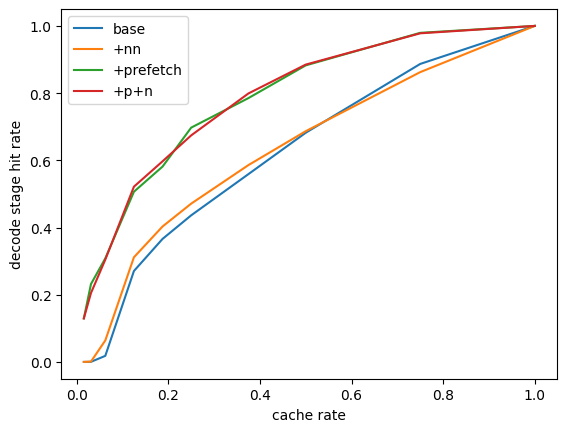

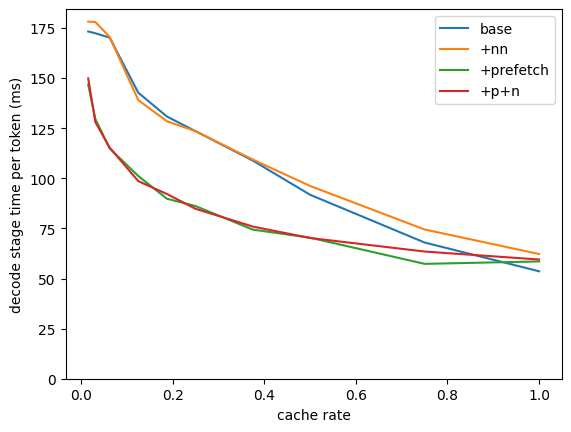

In [11]:
df = orig_df
df = df[df['per_layer_cache'] == True]
# df = df[df['num_predict_expert_per_layer'] == 0]

x = df.query('num_predict_expert_per_layer == 0').query('cache_policy == "lru"')['cache_rate']

plt.plot(x, df.query('num_predict_expert_per_layer == 0').query('cache_policy == "lru"')['decode_stage_hit_rate'], label='base')
plt.plot(x, df.query('num_predict_expert_per_layer == 0').query('cache_policy ==  "nn"')['decode_stage_hit_rate'], label='+nn')
plt.plot(x, df.query('num_predict_expert_per_layer == 6').query('cache_policy == "lru"')['decode_stage_hit_rate'], label='+prefetch')
plt.plot(x, df.query('num_predict_expert_per_layer == 6').query('cache_policy ==  "nn"')['decode_stage_hit_rate'], label='+p+n')
plt.xlabel('cache rate')
plt.ylabel('decode stage hit rate')
plt.legend()
plt.show()

plt.plot(x, df.query('num_predict_expert_per_layer == 0').query('cache_policy == "lru"')['decode_stage_forward_time']/1000, label='base')
plt.plot(x, df.query('num_predict_expert_per_layer == 0').query('cache_policy ==  "nn"')['decode_stage_forward_time']/1000, label='+nn')
plt.plot(x, df.query('num_predict_expert_per_layer == 6').query('cache_policy == "lru"')['decode_stage_forward_time']/1000, label='+prefetch')
plt.plot(x, df.query('num_predict_expert_per_layer == 6').query('cache_policy ==  "nn"')['decode_stage_forward_time']/1000, label='+p+n')

plt.xlabel('cache rate')
plt.ylabel('decode stage time per token (ms)')
plt.ylim(bottom=0)
plt.legend()
plt.show()

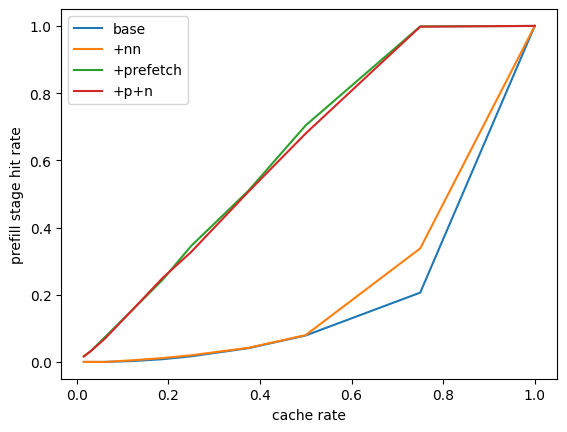

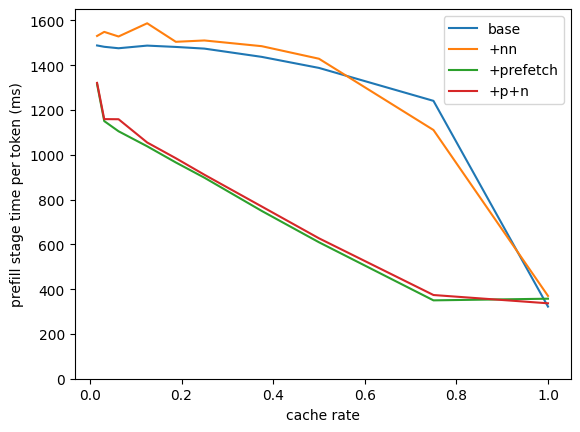

In [12]:
df = orig_df
df = df[df['per_layer_cache'] == True]
# df = df[df['num_predict_expert_per_layer'] == 0]

x = df.query('num_predict_expert_per_layer == 0').query('cache_policy == "lru"')['cache_rate']

plt.plot(x, df.query('num_predict_expert_per_layer == 0').query('cache_policy == "lru"')['prefill_stage_hit_rate'], label='base')
plt.plot(x, df.query('num_predict_expert_per_layer == 0').query('cache_policy ==  "nn"')['prefill_stage_hit_rate'], label='+nn')
plt.plot(x, df.query('num_predict_expert_per_layer == 6').query('cache_policy == "lru"')['prefill_stage_hit_rate'], label='+prefetch')
plt.plot(x, df.query('num_predict_expert_per_layer == 6').query('cache_policy ==  "nn"')['prefill_stage_hit_rate'], label='+p+n')
plt.xlabel('cache rate')
plt.ylabel('prefill stage hit rate')
plt.legend()
plt.show()

plt.plot(x, df.query('num_predict_expert_per_layer == 0').query('cache_policy == "lru"')['prefill_stage_forward_time']/1000, label='base')
plt.plot(x, df.query('num_predict_expert_per_layer == 0').query('cache_policy ==  "nn"')['prefill_stage_forward_time']/1000, label='+nn')
plt.plot(x, df.query('num_predict_expert_per_layer == 6').query('cache_policy == "lru"')['prefill_stage_forward_time']/1000, label='+prefetch')
plt.plot(x, df.query('num_predict_expert_per_layer == 6').query('cache_policy ==  "nn"')['prefill_stage_forward_time']/1000, label='+p+n')

plt.xlabel('cache rate')
plt.ylabel('prefill stage time per token (ms)')
plt.ylim(bottom=0)
plt.legend()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


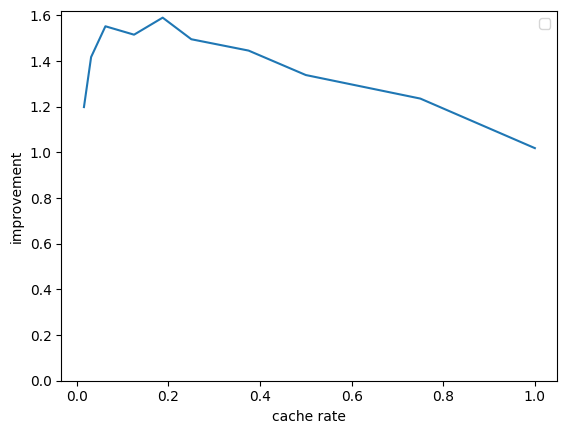

In [4]:
import numpy as np
df = orig_df
df = df[df['per_layer_cache'] == True]
x = df.query('num_predict_expert_per_layer == 0').query('reorder_experts == False').query('early_preempt == False')['cache_rate']

subset = df.query('num_predict_expert_per_layer == 0').query('reorder_experts == False').query('early_preempt == False')
y1 = np.asarray(subset['decode_stage_forward_time']/1000)
subset = df.query('num_predict_expert_per_layer == 6').query('reorder_experts == True').query('early_preempt == True')
y2 = np.asarray(subset['decode_stage_forward_time']/1000)

plt.plot(subset['cache_rate'], y1/y2)
# plt.plot(subset['cache_rate'], y2)


plt.xlabel('cache rate')
plt.ylabel('improvement')
plt.ylim(bottom=0)
plt.legend()
plt.show()